# Group 5 - Customer Segmentation

## Load dataset and Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
!pip install kmodes
from kmodes.kmodes import KModes
!pip install gower
import gower
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, fcluster
!pip install prince
import prince
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder
from scipy.cluster.hierarchy import fcluster


import warnings
warnings.filterwarnings('ignore')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
df = pd.read_excel("marketing_campaign.xlsx")

In [3]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0


In [4]:
df.tail()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
2235,10870,1967,Graduation,Married,61223.0,0,1,2013-06-13,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,2014-06-10,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,2014-01-25,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,2014-01-24,8,428,...,3,0,0,0,0,0,0,3,11,0
2239,9405,1954,PhD,Married,52869.0,1,1,2012-10-15,40,84,...,7,0,0,0,0,0,0,3,11,1


In [5]:
df.shape

(2240, 29)

In [6]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [7]:
df = df.dropna(subset = ['Income'])

## Data cleaning

### Date Handling

In [8]:
df['Dt_Customer'] = pd.to_datetime(
    df['Dt_Customer'],
    dayfirst=True,
    errors='coerce'
)

In [9]:
# Extract customer tenure features
df['Customer_Year'] = df['Dt_Customer'].dt.year
df['Customer_Month'] = df['Dt_Customer'].dt.month

### Clean Categorical Variables

In [10]:
df['Marital_Status'] = df['Marital_Status'].replace({
    'YOLO': 'Single',
    'Absurd': 'Single',
    'Alone': 'Single'
})

In [11]:
df['Education'].value_counts()

Education
Graduation    1116
PhD            481
Master         365
2n Cycle       200
Basic           54
Name: count, dtype: int64

In [12]:
df['Marital_Status'].value_counts()

Marital_Status
Married     857
Together    573
Single      478
Divorced    232
Widow        76
Name: count, dtype: int64

### Age Feature Engineering

In [13]:
df['Age'] = 2026 - df['Year_Birth']
df.drop('Year_Birth', axis=1, inplace=True)

In [14]:
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[0, 30, 40, 50, 60, 100],
    labels=['<30', '30–40', '40–50', '50–60', '60+']
)

### Family & Household Features

In [15]:
df['HasKids'] = ((df['Kidhome'] + df['Teenhome']) > 0).astype(int)
df['Family_Size'] = df['Kidhome'] + df['Teenhome'] + 1

### Income Segmentation

In [16]:
df['IncomeGroup'] = pd.qcut(
    df['Income'],
    q=4,
    labels=['Low', 'Lower-Mid', 'Upper-Mid', 'High']
)

### Spending Features

In [17]:
spending_cols = [
    'MntWines', 'MntFruits', 'MntMeatProducts',
    'MntFishProducts', 'MntSweetProducts', 'MntGoldProds'
]

df['Total_Spending'] = df[spending_cols].sum(axis=1)


In [18]:
df['SpendingLevel'] = pd.qcut(
    df['Total_Spending'],
    q=3,
    labels=['Low spender', 'Medium spender', 'High spender']
)

### Campaign Engagement

In [19]:
campaign_cols = [
    'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3',
    'AcceptedCmp4', 'AcceptedCmp5', 'Response'
]

df['CampaignEngagement'] = df[campaign_cols].sum(axis=1)

df['EngagementLevel'] = pd.cut(
    df['CampaignEngagement'],
    bins=[-1, 0, 2, 6],
    labels=['Not engaged', 'Moderately engaged', 'Highly engaged']
)

### Recency of purchase

In [20]:
df['RecencyGroup'] = pd.qcut(
    df['Recency'],
    q=4,
    labels=['Very Recent', 'Recent', 'Moderate', 'Long Ago']
)

### Discount purchase

In [21]:
df['DiscountPurchasesGroup'] = pd.qcut(
    df['NumDealsPurchases'],
    q=4,
    labels=['Very Low', 'Low', 'High', 'Very High']
)


### Web Purchase

In [22]:
df['WebPurchaseLevel'] = pd.qcut(
    df['NumWebPurchases'],
    q=4,
    duplicates='drop'
)

### Catalog Purchase

In [23]:
df['CatalogPurchaseLevel'] = pd.qcut(
    df['NumCatalogPurchases'],
    q=4,
    duplicates='drop'
)

df['CatalogPurchaseLevel'] = df['CatalogPurchaseLevel'].cat.rename_categories(
    ['Low', 'Medium', 'High']
)


### store purchase

In [24]:
df['StorePurchaseLevel'] = pd.qcut(
    df['NumStorePurchases'],
    q=4,
    duplicates='drop'
)


### Web visit

In [25]:
df['WebVisitsGroup'] = pd.qcut(
    df['NumWebVisitsMonth'],
    q=4,
    labels=['Very Low', 'Low', 'High', 'Very High']
)

### Products

In [26]:
product_cols = [
    'MntWines',
    'MntFruits',
    'MntMeatProducts',
    'MntFishProducts',
    'MntSweetProducts',
    'MntGoldProds'
]

# Binary flags: did customer buy this product type at all?
for col in product_cols:
    df[f'Bought_{col}'] = (df[col] > 0).astype(int)

### Final checks before EDA

In [27]:
df.drop(['ID'], axis=1, inplace=True)
df.drop_duplicates(inplace=True)

In [28]:
df.columns

Index(['Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome',
       'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts',
       'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
       'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
       'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3',
       'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2',
       'Complain', 'Z_CostContact', 'Z_Revenue', 'Response', 'Customer_Year',
       'Customer_Month', 'Age', 'AgeGroup', 'HasKids', 'Family_Size',
       'IncomeGroup', 'Total_Spending', 'SpendingLevel', 'CampaignEngagement',
       'EngagementLevel', 'RecencyGroup', 'DiscountPurchasesGroup',
       'WebPurchaseLevel', 'CatalogPurchaseLevel', 'StorePurchaseLevel',
       'WebVisitsGroup', 'Bought_MntWines', 'Bought_MntFruits',
       'Bought_MntMeatProducts', 'Bought_MntFishProducts',
       'Bought_MntSweetProducts', 'Bought_MntGoldProds'],
      dtype='object')

In [29]:
df.describe()

,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,HasKids,Family_Size,Total_Spending,CampaignEngagement,Bought_MntWines,Bought_MntFruits,Bought_MntMeatProducts,Bought_MntFishProducts,Bought_MntSweetProducts,Bought_MntGoldProds
count,2032.000000,2032.000000,2032.000000,2032,2032.000000,2032.000000,2032.000000,2032.000000,2032.000000,2032.000000,...,2032.000000,2032.000000,2032.000000,2032.000000,2032.000000,2032.000000,2032.000000,2032.000000,2032.000000,2032.000000
mean,52368.671260,0.442913,0.508366,2013-07-11 14:18:11.338582528,48.885335,305.320374,26.313484,167.892224,37.474902,27.159449,...,0.718504,1.951280,607.982776,0.454232,0.994094,0.821358,0.999508,0.825787,0.812992,0.971949
min,1730.000000,0.000000,0.000000,2012-07-30 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,35538.750000,0.000000,0.000000,2013-01-17 00:00:00,24.000000,23.000000,2.000000,16.000000,3.000000,1.000000,...,0.000000,1.000000,69.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
50%,51550.000000,0.000000,0.000000,2013-07-12 12:00:00,49.000000,175.500000,8.000000,68.000000,12.000000,8.000000,...,1.000000,2.000000,397.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
75%,68522.000000,1.000000,1.000000,2014-01-02 00:00:00,74.000000,505.500000,33.000000,230.000000,50.000000,34.000000,...,1.000000,2.000000,1048.250000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,666666.000000,2.000000,2.000000,2014-06-29 00:00:00,99.000000,1493.000000,199.000000,1725.000000,259.000000,262.000000,...,1.000000,4.000000,2525.000000,5.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
std,25536.184914,0.535945,0.546173,NaN,28.968533,337.423349,39.786798,226.864824,54.812427,41.510372,...,0.449840,0.745965,603.726338,0.893586,0.076639,0.383146,0.022184,0.379386,0.390014,0.165160


## Exploratory Data Analysis

### Customer Demographics

#### Age distribution

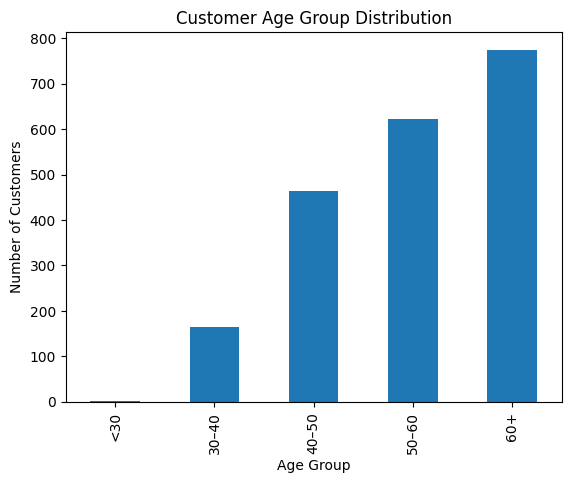

In [30]:
df['AgeGroup'].value_counts().sort_index().plot(kind='bar')
plt.title('Customer Age Group Distribution')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.show()


The customer demographic is mostly senior citizens

Company can use this for promotions targetted to people over 60, to provide more accessibility for their customers and to attract new potential customers

#### Income Distribution by Segment

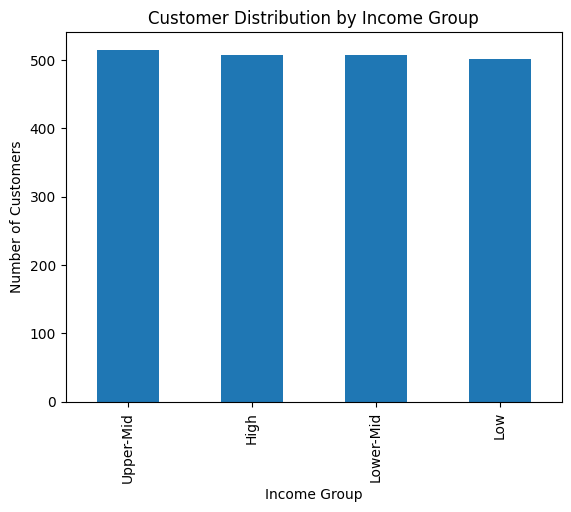

In [31]:
df['IncomeGroup'].value_counts().plot(kind='bar')
plt.title('Customer Distribution by Income Group')
plt.xlabel('Income Group')
plt.ylabel('Number of Customers')
plt.show()


### Spending Behaviour Analysis

#### Total Spending by Product Category

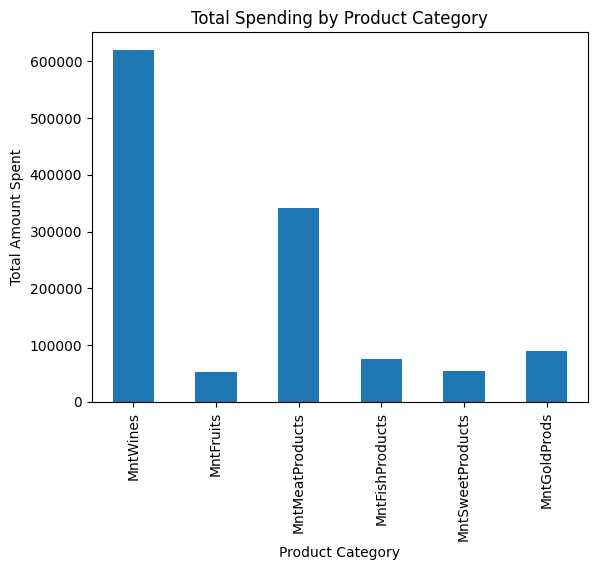

In [32]:
spending_cols = [
    'MntWines','MntFruits','MntMeatProducts',
    'MntFishProducts','MntSweetProducts','MntGoldProds'
]

df[spending_cols].sum().plot(kind='bar')
plt.title("Total Spending by Product Category")
plt.ylabel("Total Amount Spent")
plt.xlabel("Product Category")
plt.show()


The Product Categories Wine and Meat are where most of the spending is done

#### Spending Level vs Income Group

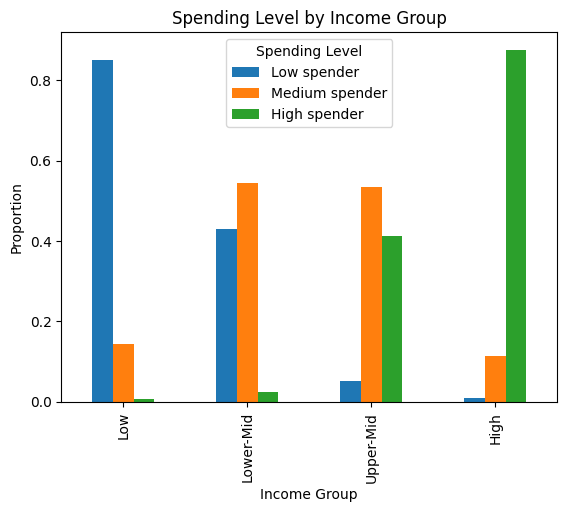

In [33]:
pd.crosstab(
    df['IncomeGroup'],
    df['SpendingLevel'],
    normalize='index'
).plot(kind='bar')
plt.title('Spending Level by Income Group')
plt.xlabel('Income Group')
plt.ylabel('Proportion')
plt.legend(title='Spending Level')
plt.show()


Lower income groups spend less

higher income groups spend more

#### Spending Level vs Household Type

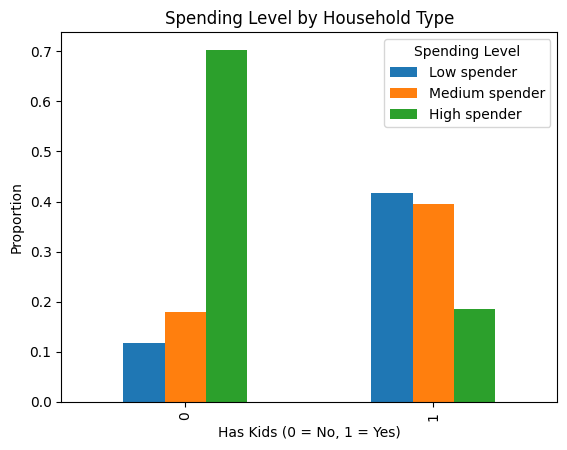

In [34]:
pd.crosstab(
    df['HasKids'],
    df['SpendingLevel'],
    normalize='index'
).plot(kind='bar')
plt.title('Spending Level by Household Type')
plt.xlabel('Has Kids (0 = No, 1 = Yes)')
plt.ylabel('Proportion')
plt.legend(title='Spending Level')
plt.show()


Those who don't have kids spend more

### Campaign Engagement Analysis

#### Engagement vs Spending Level

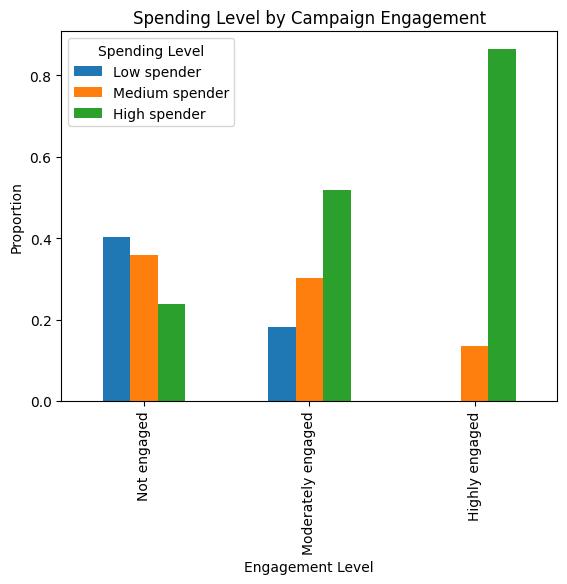

In [35]:
pd.crosstab(
    df['EngagementLevel'],
    df['SpendingLevel'],
    normalize='index'
).plot(kind='bar')
plt.title('Spending Level by Campaign Engagement')
plt.xlabel('Engagement Level')
plt.ylabel('Proportion')
plt.legend(title='Spending Level')
plt.show()


Those who are more engaged with the company spend more

#### Campaign Engagement Distribution

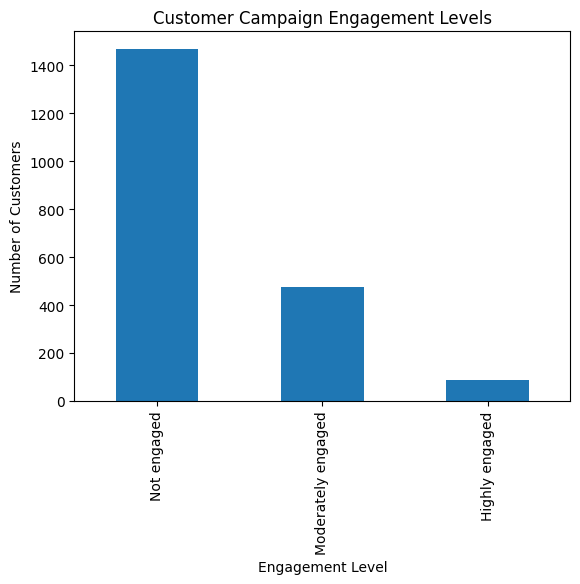

In [36]:
df['EngagementLevel'].value_counts().plot(kind='bar')
plt.title('Customer Campaign Engagement Levels')
plt.xlabel('Engagement Level')
plt.ylabel('Number of Customers')
plt.show()


There are more customers who don't engage in campaigns. In other words, there are less than 200 customers who are highly engaged in campaigns.

### Correlation Heatmap

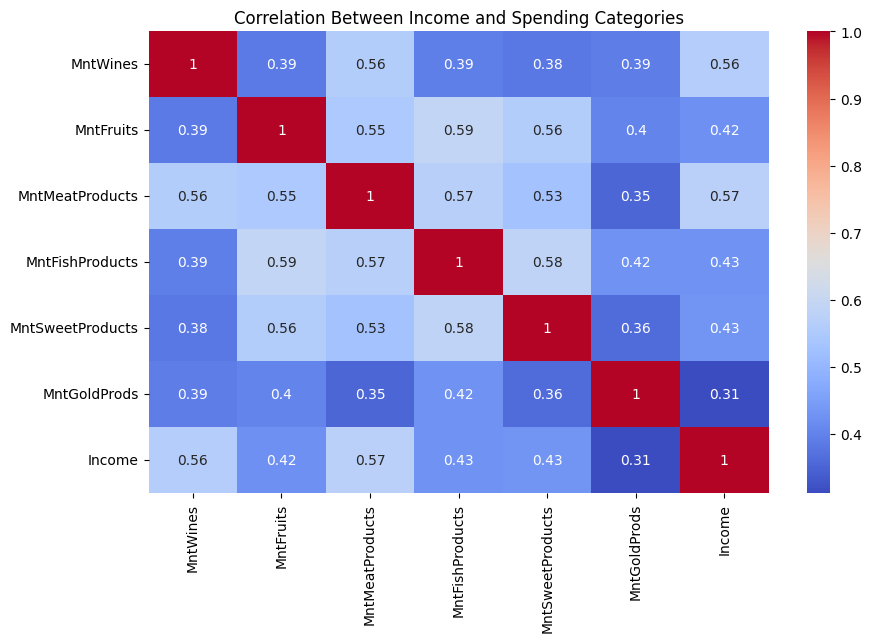

In [37]:
plt.figure(figsize=(10,6))
sns.heatmap(
    df[spending_cols + ['Income']].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Between Income and Spending Categories")
plt.show()


### Purchase Channel Behaviour

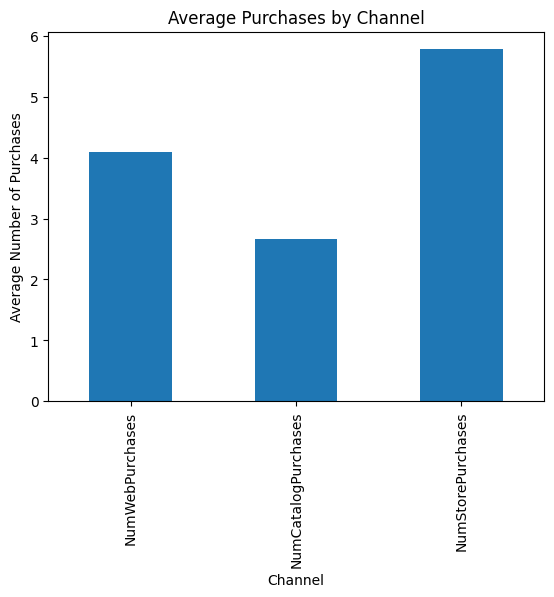

In [38]:
purchase_cols = [
    'NumWebPurchases',
    'NumCatalogPurchases',
    'NumStorePurchases'
]

df[purchase_cols].mean().plot(kind='bar')
plt.title('Average Purchases by Channel')
plt.ylabel('Average Number of Purchases')
plt.xlabel('Channel')
plt.show()

Most of the purchases are done in Store, followed by Web and Catalog purchases being the least.

### Customer Value Indicators

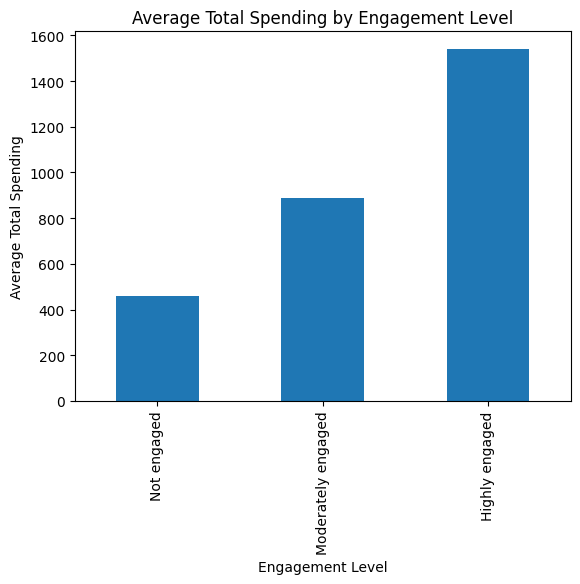

In [39]:
df.groupby('EngagementLevel')['Total_Spending'].mean().plot(kind='bar')
plt.title('Average Total Spending by Engagement Level')
plt.ylabel('Average Total Spending')
plt.xlabel('Engagement Level')
plt.show()


The more a customer is engaged in campaigns the more they spend.

## MODEL BUILDING AND MODEL EVALUATION

The objective of this project is to perform **customer personality analysis** by identifying distinct customer segments that share similar demographic, household, spending, and campaign engagement characteristics.  


As the goal is to *understand and summarise customers rather than predict an outcome*, an **unsupervised learning approach** is appropriate.


In this section, multiple clustering models are explored and compared to determine the most suitable method for customer segmentation.  
Given that the dataset consists primarily of **categorical variables**, particular emphasis is placed on models that can appropriately handle categorical data while producing **interpretable and actionable customer segments**.


The following steps are undertaken:
1. Selection of relevant customer features for segmentation
2. Application of multiple clustering techniques (K-Modes, Hierarchical Clustering with Gower Distance, and K-Means)
3. Evaluation of each model based on cluster structure, interpretability, and alignment with business objectives
4. Selection of the final clustering model that best supports the project target


The chosen model will enable the company to better understand its customer base and support targeted marketing strategies by focusing on the customer segments most likely to respond to specific campaigns.


### Hierarchical clustering with Gower's Distance

Hierarchical clustering using Gower distance was explored as it supports mixed and categorical data types and provides a hierarchical view of customer similarity.
The resulting clusters showed similar size distributions to K-Modes, indicating consistent underlying customer group structures.


However, hierarchical clustering is **computationally more expensive** and less scalable, and its cluster centroids are less directly interpretable for business use compared to K-Modes.

In [40]:
categorical_cols = [
    'AgeGroup',
    'HasKids',
    'IncomeGroup',
    'SpendingLevel',
    'EngagementLevel',
    'RecencyGroup',
    'DiscountPurchasesGroup',
    'WebPurchaseLevel',
    'CatalogPurchaseLevel',
    'StorePurchaseLevel',
    'Education',
    'Marital_Status',
    'Complain',
    'Response'
]


In [41]:
# Use categorical features directly
df_model = df[categorical_cols].astype(str)

# True Gower distance
gower_dist = gower.gower_matrix(df_model)

# Hierarchical clustering
Z = linkage(squareform(gower_dist), method='average')


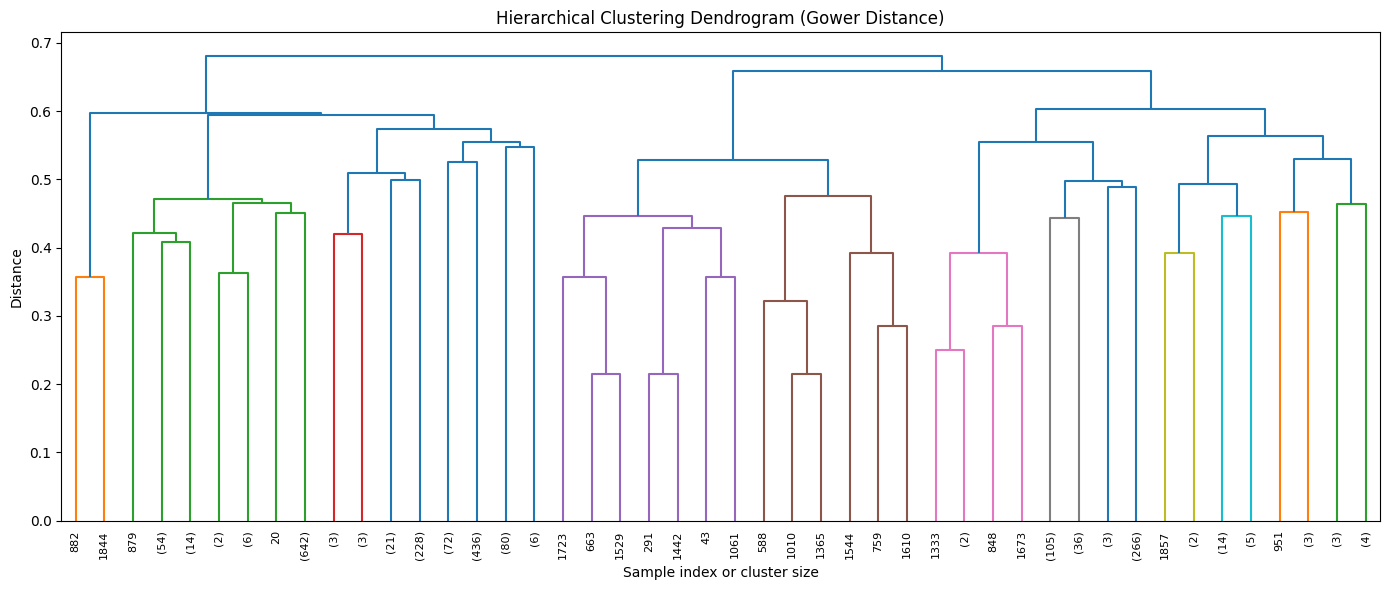

In [42]:
plt.figure(figsize=(14, 6))
dendrogram(
    Z,
    truncate_mode='level',  # cleaner for large datasets
    p=5
)

plt.title("Hierarchical Clustering Dendrogram (Gower Distance)")
plt.xlabel("Sample index or cluster size")
plt.ylabel("Distance")

plt.tight_layout()
plt.show()

Based on dendrogram inspection and interpretability, we selected 4 clusters.

In [43]:
k = 4 #we cut the dendrogram into 4 clusters
df['Hierarchical_Cluster'] = fcluster(
    Z,
    k,
    criterion='maxclust'
)

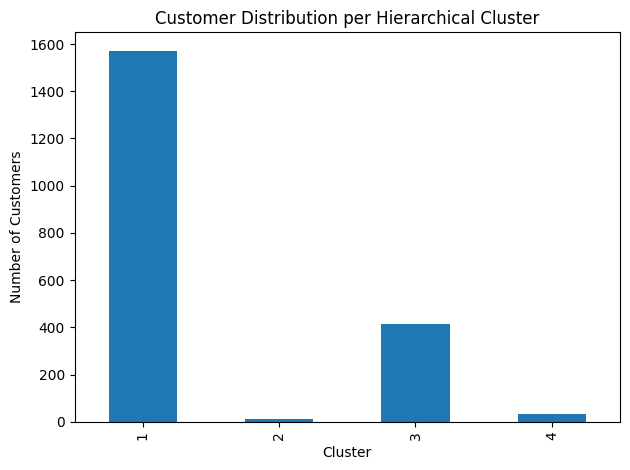

In [44]:
cluster_distribution = (
    df['Hierarchical_Cluster']
    .value_counts()
    .sort_index()
)
cluster_distribution.plot(kind='bar')
plt.title("Customer Distribution per Hierarchical Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()


In [45]:
hier_profile = (
    df
    .groupby('Hierarchical_Cluster')[categorical_cols]
    .agg(lambda x: x.mode()[0])
)

hier_profile


,AgeGroup,HasKids,IncomeGroup,SpendingLevel,EngagementLevel,RecencyGroup,DiscountPurchasesGroup,WebPurchaseLevel,CatalogPurchaseLevel,StorePurchaseLevel,Education,Marital_Status,Complain,Response
Hierarchical_Cluster,,,,,,,,,,,,,,
1,60+,1,Low,Low spender,Not engaged,Recent,Very Low,"(-0.001, 2.0]",Low,"(-0.001, 3.0]",Graduation,Married,0,0
2,60+,0,Lower-Mid,Medium spender,Moderately engaged,Very Recent,Very Low,"(2.0, 4.0]",Low,"(-0.001, 3.0]",PhD,Single,0,1
3,60+,0,High,High spender,Not engaged,Moderate,Very Low,"(2.0, 4.0]",High,"(8.0, 13.0]",Graduation,Married,0,0
4,60+,1,Upper-Mid,High spender,Moderately engaged,Long Ago,Low,"(6.0, 27.0]",High,"(3.0, 5.0]",PhD,Married,0,1


**Cluster 1**

AgeGroup: 60+

HasKids: Yes (1)

IncomeGroup: Low

SpendingLevel: Low spender

EngagementLevel: Not engaged

RecencyGroup: Recent

DiscountPurchasesGroup: Very Low

WebPurchaseLevel: (-0.001, 2.0]

CatalogPurchaseLevel: Low

StorePurchaseLevel: (-0.001, 3.0]

Education: Graduation

Marital_Status: Married

Complain: 0

Response: 0



**Cluster 2**

AgeGroup: 60+

HasKids: No (0)

IncomeGroup: Lower-Mid

SpendingLevel: Medium spender

EngagementLevel: Moderately engaged

RecencyGroup: Very Recent

DiscountPurchasesGroup: Very Low

WebPurchaseLevel: (2.0, 4.0]

CatalogPurchaseLevel: Low

StorePurchaseLevel: (-0.001, 3.0]

Education: PhD

Marital_Status: Single

Complain: 0

Response: 1

**Cluster 3**

AgeGroup: 60+

HasKids: No (0)

IncomeGroup: High

SpendingLevel: High spender

EngagementLevel: Not engaged

RecencyGroup: Moderate

DiscountPurchasesGroup: Very Low

WebPurchaseLevel: (2.0, 4.0]

CatalogPurchaseLevel: High

StorePurchaseLevel: (8.0, 13.0]

Education: Graduation

Marital_Status: Married

Complain: 0

Response: 0

**Cluster 4**

AgeGroup: 60+

HasKids: Yes (1)

IncomeGroup: Upper-Mid

SpendingLevel: High spender

EngagementLevel: Moderately engaged

RecencyGroup: Long Ago

DiscountPurchasesGroup: Low

WebPurchaseLevel: (6.0, 27.0]

CatalogPurchaseLevel: High

StorePurchaseLevel: (3.0, 5.0]

Education: PhD

Marital_Status: Married

Complain: 0

Response: 1

In [46]:
df['Hierarchical_Cluster'].value_counts().sort_index()


Hierarchical_Cluster
1    1571
2      13
3     415
4      33
Name: count, dtype: int64

In [47]:
#df_clean.to_csv("clustered_customers.csv", index=False)

### Chosen model 

Hierarchical clustering with gower's distance

## Deployment with Streamlit